In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from collections import defaultdict
from tqdm import tqdm
from scipy.optimize import minimize_scalar
from scipy.ndimage import convolve

import time
from sklearn.gaussian_process.kernels import Matern

import torch
import torch.nn.functional as F
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, RandomWalkKernel

import sys
sys.path.append("../../../")
from LRM.plotting import set_plot_style
from LRM.PottsModel import PottsModel
set_plot_style()



## Helpers (simulation)

In [3]:
#Helper functions used throughout
def get_full_neighbors(i : int, j : int, L1 : int, L2 : int):
    """Returns indices of four nearest neighbours assuming periodic boundary conditions.

    Args:
        i (int): ith row
        j (int): jth column
        L1 (int): number of rows (max row index)
        L2 (int): number of columns (max column index)

    Returns:
        _type_: tuple of pairs of indices
    """
    return [(i-1)%L1, j], [(i+1)%L1, j], [i, (j-1)%L2], [i, (j+1)%L2]


def get_half_neighbors(i : int, j : int, L1 : int, L2 : int):
    """Returns indices of four nearest neighbours assuming periodic boundary conditions.

    Args:
        i (int): ith row
        j (int): jth column
        L1 (int): number of rows (max row index)
        L2 (int): number of columns (max column index)

    Returns:
        _type_: tuple of pairs of indices
    """
    return [(i+1)%L1, j], [i, (j+1)%L2]


def unnormalized_prob(s, neighbours, T):
        return np.exp( (1/T) * sum([int(s == n) for n in neighbours]) )

def glauber_step(past_grid, T):
    
    grid = past_grid.copy()
    L = grid.shape[0]
    Xi = np.unique(grid)

    for _ in range(L * L):
        #Step 1) Randomly select a site (i,j)
        i, j = np.random.randint(0, L, size=2) 

        #Step 2) Compute conditional probability p(s | neighbours)
        neighbors = [ grid[ni, nj] for (ni,nj) in get_full_neighbors(i, j, grid.shape[0], grid.shape[1]) ]
        probs = np.array([unnormalized_prob(s, neighbors, T) for s in Xi])
        probs /= np.sum(probs)

        #Step 3) Sample new state from conditional
        grid[i, j] = np.random.choice(Xi, p=probs)
            
    return grid

def animate_grid_sequence(grid_sequence, interval=100):
    """
    Quickly animate a sequence of 2D grids stored in a 3D NumPy array.
    
    Parameters:
    - grid_sequence: np.ndarray of shape (n_steps, L, L)
    - interval: Delay between frames in milliseconds
    """
    fig, ax = plt.subplots(figsize=(2,2))
    im = ax.imshow(grid_sequence[0], cmap='tab20', vmin=0, vmax=grid_sequence.max())
    ax.axis('off')

    def update(frame):
        im.set_data(grid_sequence[frame])
        ax.set_title(f"Step {frame}")
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=len(grid_sequence), interval=interval, blit=True)
    plt.close()
    return ani



def simulate_potts(L=100, q=4, T=4.0, n_sweeps=20):

    grid = np.random.choice(a=q, size = (L, L))

    for _ in range(n_sweeps):
        grid = glauber_step(past_grid=grid, T=T)

    return grid


def simulate_potts_dynamics(L=100, q=4, T0=5.0, ts = np.linspace(0, 10, 25), cooling_schedule = None):
    """
    Simulate the Potts model using Glauber dynamics with Geman-Geman cooling.

    Parameters:
    - L (int): Grid size (L x L)
    - q (int): Number of Potts states
    - T0 (float): Initial temperature
    - steps (int): Number of time steps

    Returns:
    - state_history (ndarray): Array of shape (steps, L, L) storing the system state at each step
    """
    t0 = ts[0]

    if cooling_schedule is None: 
        cooling_schedule = lambda t: T0 / np.log(2 + t) * np.log(2 + ts[0])
        
    state_history = np.zeros((len(ts), L, L), dtype=np.int32)


    print("Initial Phase (t=0)...")
    state_history[0] = simulate_potts(L=L, q=q, T=T0)

    temps = [T0]

    print("Cooling...")
    for t_idx in tqdm(range(1, len(ts))):
        T = cooling_schedule(ts[t_idx])
        state_history[t_idx] = glauber_step(past_grid=state_history[t_idx - 1], T=T) #get new equilibrium
        temps.append(T)


    return state_history, np.array(temps)



## 1) Simulate at varying temperatures

Initial Phase (t=0)...
Cooling...


100%|██████████| 49/49 [00:10<00:00,  4.72it/s]


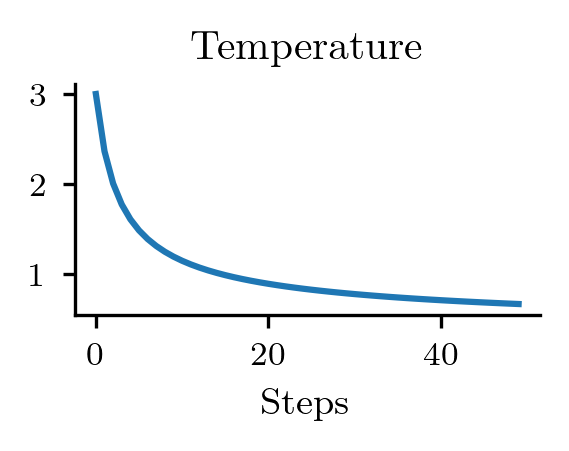

In [4]:
#Generating Potts grid with cooling schedule
ts=np.linspace(0, 20, 50)

state_history, temps = simulate_potts_dynamics(L=100, q=4, T0=3, ts=ts, cooling_schedule=None)

plt.figure(figsize=(2,1))
plt.plot(temps)
plt.title("Temperature")
plt.xlabel('Steps')

ani = animate_grid_sequence(state_history, interval=100)
HTML(ani.to_jshtml())

## 2) Inference

In [5]:
# === Pyro model ===


#----Discrete Fisher Divergence------
def get_all_neighbors(grid):
    """
    Returns a (4, H, W) tensor with neighbor values (up, down, left, right)
    """
    return torch.stack([
        torch.roll(grid, shifts=1, dims=0),   # up
        torch.roll(grid, shifts=-1, dims=0),  # down
        torch.roll(grid, shifts=1, dims=1),   # left
        torch.roll(grid, shifts=-1, dims=1),  # right
    ], dim=0)  # shape: (4, H, W)

def torch_log_prob(spin, neighbors, T):
    """
    Vectorized log-prob: log P(spin | neighbors) ∝ β * (# matches)
    spin: (H, W) tensor
    neighbors: (4, H, W) tensor
    T: scalar temperature
    Returns: (H, W) tensor of log unnormalized probabilities
    """
    beta = 1.0 / T
    match_count = (neighbors == spin).sum(dim=0)
    return beta * match_count  # log unnormalized prob

def torch_DSM(T, grid, beta=0.05):
    """
    DSM loss function, vectorized using torch.roll for neighbor access.
    grid: (H, W) tensor of integers in {0, ..., q-1}
    T: scalar temperature
    """
    if T < 0.0:
        return -torch.inf
    
    q = 4  # number of Potts states (adjust if needed)
    H, W = grid.shape
    neighbors = get_all_neighbors(grid)  # (4, H, W)

    spin = grid
    spin_plus = (grid + 1) % q
    spin_minus = (grid - 1) % q

    p = torch_log_prob(spin, neighbors, T)
    p_plus = torch_log_prob(spin_plus, neighbors, T)
    p_minus = torch_log_prob(spin_minus, neighbors, T)

    loss = torch.exp(p_minus - p)**2 - 2 * torch.exp(p - p_plus)

    return - beta * loss.sum()


#-----Pseudo-likelihood--------

def torch_pseudo_log_likelihood(T, grid, q=4):
    """
    Compute the pseudo-log-likelihood for the Potts model:
        sum_{i,j} log P(x_ij | neighbors)

    Args:
        T: temperature (float or scalar tensor)
        grid: (H, W) torch.LongTensor with values in {0, ..., q-1}
        q: number of states (int)

    Returns:
        Scalar torch tensor: total pseudo-log-likelihood
    """
    assert isinstance(grid, torch.Tensor)
    assert grid.dim() == 2
    H, W = grid.shape
    beta = 1.0 / T
    device = grid.device
    dtype = torch.float32

    if T < 0.0:
        return -torch.inf

    # Get neighbor values using torch.roll (periodic boundary conditions)
    neighbors = torch.stack([
        torch.roll(grid, shifts=1, dims=0),   # up
        torch.roll(grid, shifts=-1, dims=0),  # down
        torch.roll(grid, shifts=1, dims=1),   # left
        torch.roll(grid, shifts=-1, dims=1),  # right
    ])  # shape: (4, H, W)

    # For each state s ∈ {0, ..., q-1}, count number of neighbors equal to s
    # Result: (q, H, W) tensor where entry [s, i, j] = N_s at (i, j)
    neighbor_counts = torch.stack([
        (neighbors == s).sum(dim=0).to(dtype)
        for s in range(q)
    ])  # shape: (q, H, W)

    # Get N_{x_ij}: number of neighbors matching the actual label at each site
    # grid: (H, W) → (1, H, W) for indexing
     # Get observed label counts N_{x_ij} for each site
     
    x_idx = grid.long().unsqueeze(0)  # (1, H, W), dtype=int64
    N_obs = torch.gather(neighbor_counts, dim=0, index=x_idx).squeeze(0)  # (H, W)

    # Compute log P(x_ij | neighbors)
    log_numer = beta * N_obs  # (H, W)
    log_denom = torch.logsumexp(beta * neighbor_counts, dim=0)  # (H, W)

    log_probs = log_numer - log_denom
    return log_probs.sum()


#----Pyro model---------
def model(grid, posterior="DSM"):
    #T_inv = pyro.sample("T", dist.Uniform(0.1, 10.0))
    T_inv = pyro.sample("T", dist.Normal(0.5, np.sqrt(10)))  

    if posterior == "DSM":
        log_lik = torch_DSM(1/T_inv, grid)

    elif posterior == "PL":
        log_lik = torch_pseudo_log_likelihood(1/T_inv, grid)
    else:
        raise ValueError(f"Unknown posterior: {posterior}")

    pyro.factor("pseudo_likelihood", log_lik)

# === MCMC runner ===
def run_mcmc_pyro(grid, posterior="DSM", num_samples=1000, warmup_steps=500):
    kernel = RandomWalkKernel(model)
    mcmc = MCMC(kernel, num_samples=num_samples, warmup_steps=warmup_steps)
    mcmc.run(grid, posterior=posterior)
    return mcmc.get_samples()


### Get times

In [6]:
def get_times(posterior = "DSM"):
    num_samples_arr = [500, 1000, 2500, 3000, 3500, 4000, 4500, 5000]
    times_arr = []

    for num_samples in num_samples_arr:
        arr = []
        mean_arr = []

        for _ in range(10):
            t1 = time.time()
            samples = run_mcmc_pyro(torch.from_numpy(state_history[10]), posterior=posterior, num_samples=num_samples, warmup_steps=500)
            t2 = time.time()
            arr.append(t2 - t1)

        times_arr.append(arr)

    return num_samples_arr, times_arr


In [8]:
"""

#Run only if needed

num_samples_arr, times_arr_DSM = get_times("DSM")
num_samples_arr, times_arr_PL = get_times("PL")
np.savez("./outputs/mcmc_samples_vs_times.npz", num_samples_arr = num_samples_arr, times_arr_DSM = np.array(times_arr_DSM), times_arr_PL = np.array(times_arr_PL))
"""

'\n\n#Run only if needed\n\nnum_samples_arr, times_arr_DSM = get_times("DSM")\nnum_samples_arr, times_arr_PL = get_times("PL")\nnp.savez("./outputs/mcmc_samples_vs_times.npz", num_samples_arr = num_samples_arr, times_arr_DSM = np.array(times_arr_DSM), times_arr_PL = np.array(times_arr_PL))\n'

### Get DFD/DSM and PL posteriors

In [9]:
def get_mcmc_posteriors(posterior="DSM", num_samples=2000):
    mean_arrs = []
    std_arrs = []
    
    for _ in range(20):
        mean_arr = []
        std_arr = []

        #generate a state history
        state_history, temps = simulate_potts_dynamics(L=100, q=4, T0=3, ts=ts, cooling_schedule=None)

        #for each grid in the state history, compute the mean/std via MCMC sampling
        for grid in state_history:
        
            samples = run_mcmc_pyro(torch.from_numpy(grid), posterior=posterior, num_samples=num_samples, warmup_steps=500)
            mean_arr.append(samples["T"].mean())
            std_arr.append(samples["T"].std())
            
        #store the estimates for that dataset
        mean_arrs.append(mean_arr)
        std_arrs.append(std_arr)

    return mean_arrs, std_arrs


In [11]:
#RUN ONLY IF NEEDED
"""
mcmc_posterior_DSM = get_mcmc_posteriors(posterior="DSM", num_samples=2000);
mcmc_posterior_PL = get_mcmc_posteriors(posterior="PL", num_samples=2000);

#Only save the mean_arrs
np.savez("outputs/mcmc_posterior_means_dsm.npz", means=np.array(mcmc_posterior_DSM[0]))
np.savez("outputs/mcmc_posterior_means_PL.npz", means=np.array(mcmc_posterior_PL[0]))
"""

'\nmcmc_posterior_DSM = get_mcmc_posteriors(posterior="DSM", num_samples=2000);\nmcmc_posterior_PL = get_mcmc_posteriors(posterior="PL", num_samples=2000);\n\n#Only save the mean_arrs\nnp.savez("outputs/mcmc_posterior_means_dsm.npz", means=np.array(mcmc_posterior_DSM[0]))\nnp.savez("outputs/mcmc_posterior_means_PL.npz", means=np.array(mcmc_posterior_PL[0]))\n'

### LRM times and posteriors

In [12]:
def get_posterior(state_history, prior_mean=0.5, prior_var=5.0):
    preds = []
    errs = []

    for i in tqdm(range(len(temps))):
        pmodel = PottsModel(grid=state_history[i], alpha=0.0)
        beta_hat, cov_hat, res = pmodel.fit_coverage(prior_mean=prior_mean, prior_var=prior_var, beta_high=1., B=200)
        mu_post, cov_post = pmodel.posterior(beta=beta_hat, prior_mean=prior_mean, prior_var=prior_var)

        preds.append(mu_post)
        errs.append(3*np.sqrt(np.abs(cov_post)))

    preds = np.array(preds)
    errs = np.array(errs)

    return errs, preds

In [13]:
#LRM inference
"""t1 = time.time()
errs, mu_posterior = get_posterior(state_history)
t2 = time.time()

np.savetxt("./outputs/mu_posterior_LRM_simulated_Potts.txt", mu_posterior)
np.savetxt("./outputs/errs_LRM_simulated_Potts.txt", errs)

print((t2 - t1) / 50)"""

't1 = time.time()\nerrs, mu_posterior = get_posterior(state_history)\nt2 = time.time()\n\nnp.savetxt("./outputs/mu_posterior_LRM_simulated_Potts.txt", mu_posterior)\nnp.savetxt("./outputs/errs_LRM_simulated_Potts.txt", errs)\n\nprint((t2 - t1) / 50)'

In [14]:
mu_posterior = np.loadtxt("./outputs/mu_posterior_LRM_simulated_Potts.txt")
errs = np.loadtxt("./outputs/errs_LRM_simulated_Potts.txt")

In [15]:
#Only for LRM computational time
lrm_times = []
for _ in range(20):    
    t1 = time.time()
    mod = PottsModel(grid=state_history[0], alpha=0.0)
    mod.posterior(beta=1.0, prior_mean=0.5, prior_var=10.) #beta is fixed here since we only check comp. time.
    t2 = time.time()
    lrm_times.append(t2 - t1)

lrm_time = np.mean(lrm_times)
print(lrm_time, np.std(lrm_times))

0.00974363088607788 0.01736108061780846


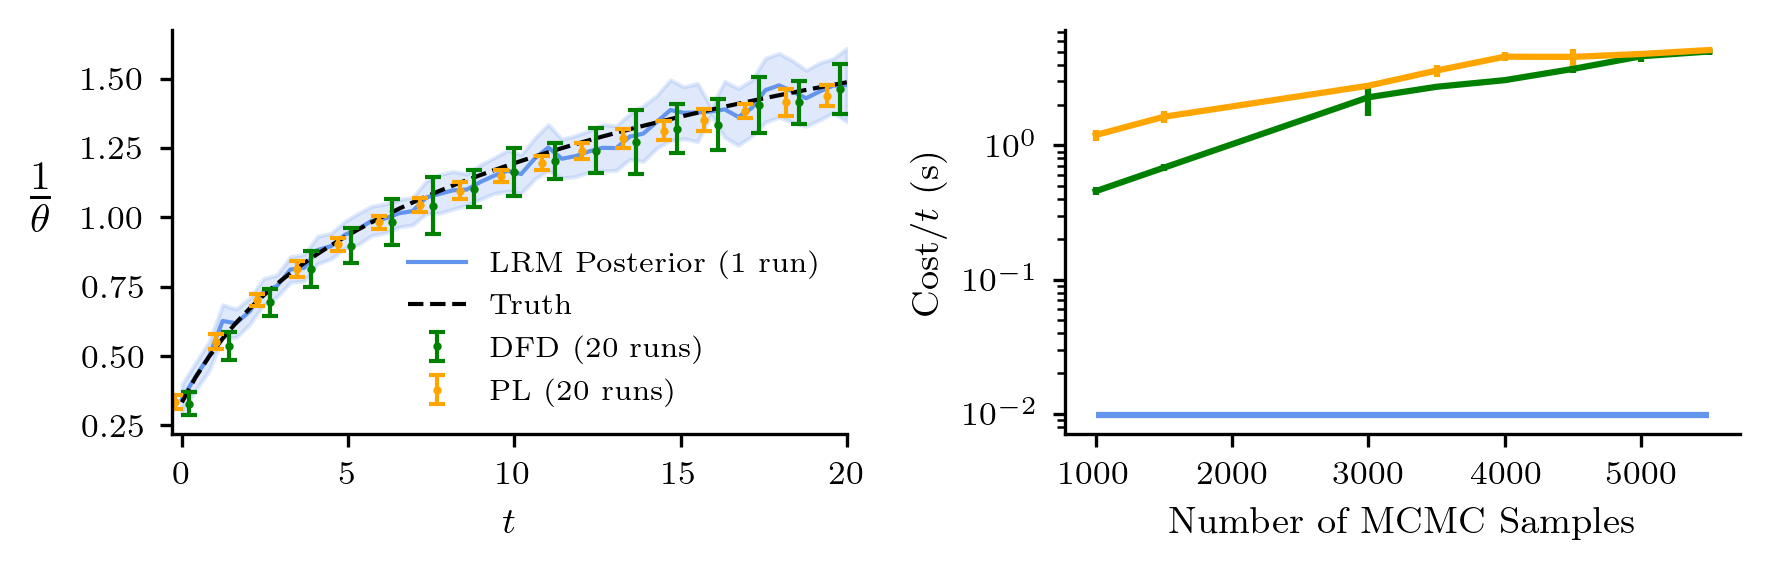

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6, 2))

mean_DSM = np.load("outputs/mcmc_posterior_means_dsm.npz")["means"].mean(axis=0)
std_DSM = np.load("outputs/mcmc_posterior_means_dsm.npz")["means"].std(axis=0)

mean_PL = np.load("outputs/mcmc_posterior_means_PL.npz")["means"].mean(axis=0)
std_PL = np.load("outputs/mcmc_posterior_means_PL.npz")["means"].std(axis=0)

axs[0].plot(ts, mu_posterior, color='cornflowerblue', linewidth=1, label="LRM Posterior (1 run)")
axs[0].fill_between(ts, mu_posterior - errs, mu_posterior + errs, color='cornflowerblue', alpha=0.2)
axs[0].plot(ts, 1/temps, '--', color='black', linewidth=1, label="Truth")

axs[0].set_xlim(ts[0]-0.3, ts[-1])
axs[0].set_xlabel(r"$t$")

skip = 3
axs[0].errorbar(ts[::skip] + 0.2, mean_DSM[::skip], yerr=1.96 * std_DSM[::skip], markersize=1, color='green', linewidth=1, fmt='o', capsize=2, label=r"DFD (20 runs)")
axs[0].errorbar(ts[::skip] - 0.2, mean_PL[::skip], yerr=1.96 * std_PL[::skip], markersize=1, color='orange', linewidth=1, fmt='o', capsize=2, label=r"PL (20 runs)")


axs[0].set_ylabel(r"$\frac{1}{\theta}$", rotation=0, labelpad=10, fontsize=14)

axs[0].legend(fontsize=7, frameon=False)


times_data = np.load("./outputs/mcmc_samples_vs_times.npz", allow_pickle=True)

axs[1].errorbar(times_data["num_samples_arr"] + 500,
                times_data["times_arr_DSM"].mean(axis=1),
                yerr=times_data["times_arr_DSM"].std(axis=1),
                label="DSM",
                color='green')

axs[1].errorbar(times_data["num_samples_arr"] + 500,
                times_data["times_arr_PL"].mean(axis=1),
                yerr=times_data["times_arr_PL"].std(axis=1),
                label="PL",
                color='orange')

axs[1].set_xlabel("Number of MCMC Samples")
axs[1].set_ylabel(f"Cost/$t$ (s)")
axs[1].hlines(lrm_time, 1000, 5500, color='cornflowerblue')
axs[1].set_yscale('log')

plt.tight_layout()
#plt.savefig("./results/Potts-model-temp-sim.pdf", format="pdf", bbox_inches='tight')